In [1]:
# ==============================
# STEP 1: LOAD DATA + VERIFY
# ==============================

import pandas as pd

# Load datasets
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")

# ------------------------------
# VERIFY DATA LOADED CORRECTLY
# ------------------------------

print("Orders shape:", orders.shape)
print("Customers shape:", customers.shape)
print("Payments shape:", payments.shape)
print("Order Items shape:", order_items.shape)

# Preview data
print("\nOrders sample:")
print(orders.head())

print("\nCustomers sample:")
print(customers.head())

Orders shape: (99441, 8)
Customers shape: (110981, 5)
Payments shape: (103886, 5)
Order Items shape: (112650, 7)

Orders sample:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_

In [2]:
# ==============================
# STEP 2: MERGE DATASETS
# ==============================

# Convert timestamp to datetime (important for later)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# ------------------------------
# MERGE ALL TABLES (LEFT JOINS)
# ------------------------------

df = orders.merge(payments, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(order_items, on='order_id', how='left')

# ------------------------------
# VERIFY MERGE
# ------------------------------

print("Final merged shape:", df.shape)

print("\nColumns in dataset:")
print(df.columns)

print("\nSample data:")
print(df.head())

Final merged shape: (132228, 22)

Columns in dataset:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

Sample data:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
4  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb625

Monthly Revenue Data:
     month  payment_value
0  2016-09         463.53
1  2016-10       80382.84
2  2016-12          19.62
3  2017-01      210219.79
4  2017-02      390470.52


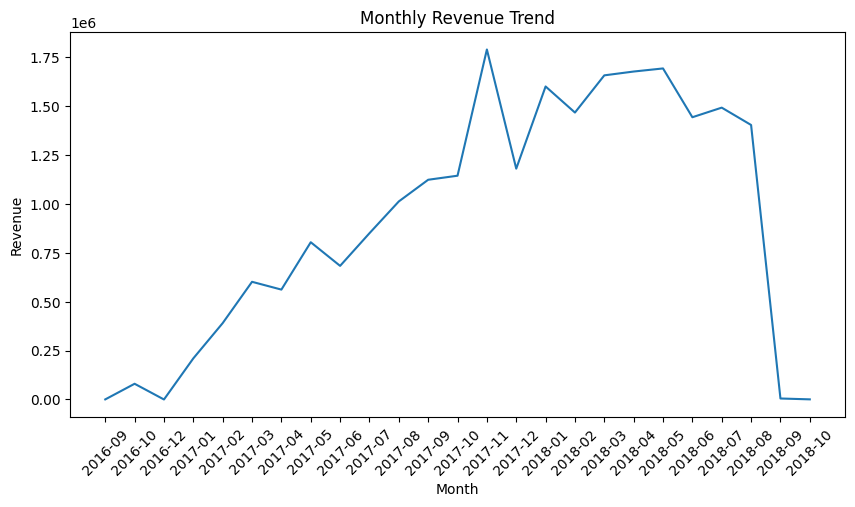

In [3]:
# ==============================
# STEP 3: MONTHLY REVENUE ANALYSIS
# ==============================

# Create month column
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = df.groupby('month')['payment_value'].sum().reset_index()

# Convert month to string (for plotting)
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

# ------------------------------
# OUTPUT
# ------------------------------

print("Monthly Revenue Data:")
print(monthly_revenue.head())

# ------------------------------
# PLOT
# ------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['month'], monthly_revenue['payment_value'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Customer Segmentation Count:
segment
New       93099
Repeat     2997
Name: count, dtype: int64


<Axes: title={'center': 'Customer Segmentation'}, xlabel='segment'>

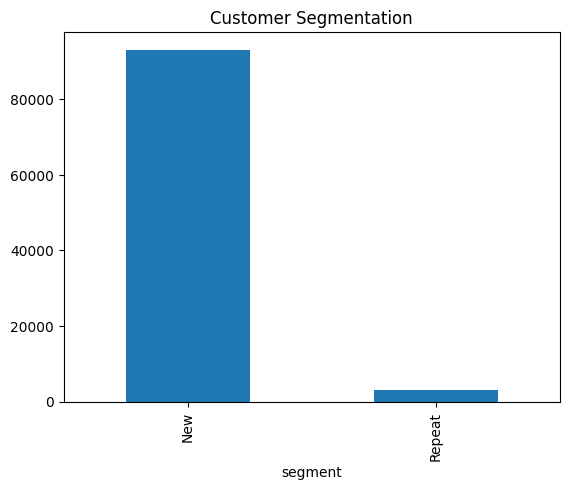

In [4]:
# ==============================
# STEP 4: CUSTOMER SEGMENTATION
# ==============================

# Count number of orders per customer (REAL customer ID)
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']

# Create customer segment
customer_orders['segment'] = customer_orders['total_orders'].apply(
    lambda x: "New" if x == 1 else "Repeat"
)

# ------------------------------
# OUTPUT
# ------------------------------

print("Customer Segmentation Count:")
print(customer_orders['segment'].value_counts())

# ------------------------------
# PLOT
# ------------------------------

customer_orders['segment'].value_counts().plot(kind='bar', title='Customer Segmentation')

Revenue by Segment:
segment
New       21323477.39
Repeat     1547349.91
Name: payment_value, dtype: float64


<Axes: title={'center': 'Revenue by Customer Type'}, xlabel='segment'>

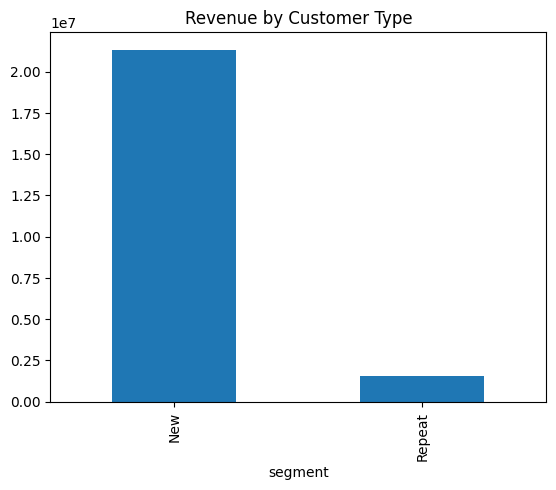

In [5]:
# ==============================
# STEP 5: REVENUE BY CUSTOMER SEGMENT
# ==============================

# Merge segmentation back into main dataframe
df = df.merge(customer_orders, on='customer_unique_id', how='left')

# Calculate revenue by segment
revenue_segment = df.groupby('segment')['payment_value'].sum()

# ------------------------------
# OUTPUT
# ------------------------------

print("Revenue by Segment:")
print(revenue_segment)

# ------------------------------
# PLOT
# ------------------------------

revenue_segment.plot(kind='bar', title='Revenue by Customer Type')

In [6]:
# ==============================
# STEP 6: COHORT ANALYSIS (SIMPLIFIED)
# ==============================

# Create order month
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# First purchase month (cohort)
cohort = df.groupby('customer_unique_id')['order_month'].min().reset_index()
cohort.columns = ['customer_unique_id', 'cohort_month']

# Merge cohort info back
df = df.merge(cohort, on='customer_unique_id')

# ------------------------------
# CALCULATE RETENTION
# ------------------------------

# Count customers per cohort vs order month
cohort_data = df.groupby(['cohort_month', 'order_month'])['customer_unique_id'].nunique().reset_index()

# Pivot table
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='order_month', values='customer_unique_id')

print(cohort_pivot.head())

order_month   2016-09  2016-10  2016-12  2017-01  2017-02  2017-03  2017-04  \
cohort_month                                                                  
2016-09           4.0      NaN      NaN      NaN      NaN      NaN      NaN   
2016-10           NaN    321.0      NaN      NaN      NaN      NaN      1.0   
2016-12           NaN      NaN      1.0      1.0      NaN      NaN      NaN   
2017-01           NaN      NaN      NaN    764.0      3.0      2.0      1.0   
2017-02           NaN      NaN      NaN      NaN   1752.0      4.0      5.0   

order_month   2017-05  2017-06  2017-07  ...  2018-01  2018-02  2018-03  \
cohort_month                             ...                              
2016-09           NaN      NaN      NaN  ...      NaN      NaN      NaN   
2016-10           NaN      NaN      1.0  ...      1.0      NaN      1.0   
2016-12           NaN      NaN      NaN  ...      NaN      NaN      NaN   
2017-01           3.0      1.0      4.0  ...      6.0      3.0      1.0

In [8]:
# ==============================
# STEP 7 FIX: CORRECT RETENTION %
# ==============================

# Function to normalize each row by its first valid value
def normalize_row(row):
    first = row[row.first_valid_index()]
    return row / first

# Apply row-wise normalization
retention = cohort_pivot.apply(normalize_row, axis=1)

# Convert to percentage
retention = retention * 100

print(retention.head())

order_month   2016-09  2016-10  2016-12  2017-01    2017-02   2017-03  \
cohort_month                                                            
2016-09         100.0      NaN      NaN      NaN        NaN       NaN   
2016-10           NaN    100.0      NaN      NaN        NaN       NaN   
2016-12           NaN      NaN    100.0    100.0        NaN       NaN   
2017-01           NaN      NaN      NaN    100.0    0.39267  0.261780   
2017-02           NaN      NaN      NaN      NaN  100.00000  0.228311   

order_month    2017-04   2017-05   2017-06   2017-07  ...   2018-01   2018-02  \
cohort_month                                          ...                       
2016-09            NaN       NaN       NaN       NaN  ...       NaN       NaN   
2016-10       0.311526       NaN       NaN  0.311526  ...  0.311526       NaN   
2016-12            NaN       NaN       NaN       NaN  ...       NaN       NaN   
2017-01       0.130890  0.392670  0.130890  0.523560  ...  0.785340  0.392670   
20

In [9]:
df.to_csv("final_dataset.csv", index=False)

In [10]:
from google.colab import files
files.download("final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>